# Fig 3c — TME marker dot plots

Dot plots of canonical tumor microenvironment (TME) marker genes across Leiden
clusters derived from Geneformer embedding–based neighbor graphs.

For each model variant the notebook:

1. loads embedding AnnData and clusters cells in embedding space;
2. transfers cluster labels onto the shared BRCA expression matrix;
3. saves publication-resolution dot plots (PNG at 450 dpi, plus PDF and SVG) with enlarged fonts for multi-panel layouts.

Outputs are written to:

- `./plots/` — figure files (`dotplot_geneformer_v1_continue`, `dotplot_gf2_continue`)
- `./fig3_metrics/` — underlying tables and auto-generated figure captions


In [1]:
from pathlib import Path
import importlib

import anndata as ad

import fig3_dotplot_utils
importlib.reload(fig3_dotplot_utils)

from fig3_dotplot_utils import (
    TME_MARKER_DICT,
    cluster_from_embedding,
    make_publication_dotplot,
    transfer_clusters,
)

PLOTS_DIR = Path("./plots")
METRICS_DIR = Path("./fig3_metrics")
PLOTS_DIR.mkdir(exist_ok=True)
METRICS_DIR.mkdir(exist_ok=True)

LEIDEN_RESOLUTION = 0.3

EMBEDDING_KEY = "X_geneformer"
CLUSTER_KEY = "cluster"
REFERENCE_DATA_PATH = Path.home() / "mnt/DATA/brca_full/cells_only_13gigs.h5ad"

MODELS = [
    {
        "label": "Geneformer V1 continue",
        "embedding_path": Path(
            "~/mnt/__output_v7/exp/geneformer/V1-10M-i2048/"
            "brca_cell_type_continue_geneformer_V1-10M-i2048_continue_brca_cell_type/data.h5ad"
        ).expanduser(),
        "output_stem": PLOTS_DIR / "dotplot_geneformer_v1_continue",
    },
    {
        "label": "Geneformer V2 continue",
        "embedding_path": Path(
            "~/mnt/__output_v7/exp/geneformer/V2-104M-i4096/"
            "brca_cell_type_continue_geneformer_V2-104M-i4096_continue_brca_cell_type/data.h5ad"
        ).expanduser(),
        "output_stem": PLOTS_DIR / "dotplot_gf2_continue",
    },
]


In [2]:
reference = ad.read_h5ad(REFERENCE_DATA_PATH)
reference = reference[reference.obs.timepoint == "Pre"].copy()

print(f"Reference cells: {reference.n_obs:,}")
print(f"Reference genes: {reference.n_vars:,}")


Reference cells: 26,697
Reference genes: 25,610



=== Geneformer V1 continue ===
Embedded cells: 26,697


/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Leiden clusters: 10


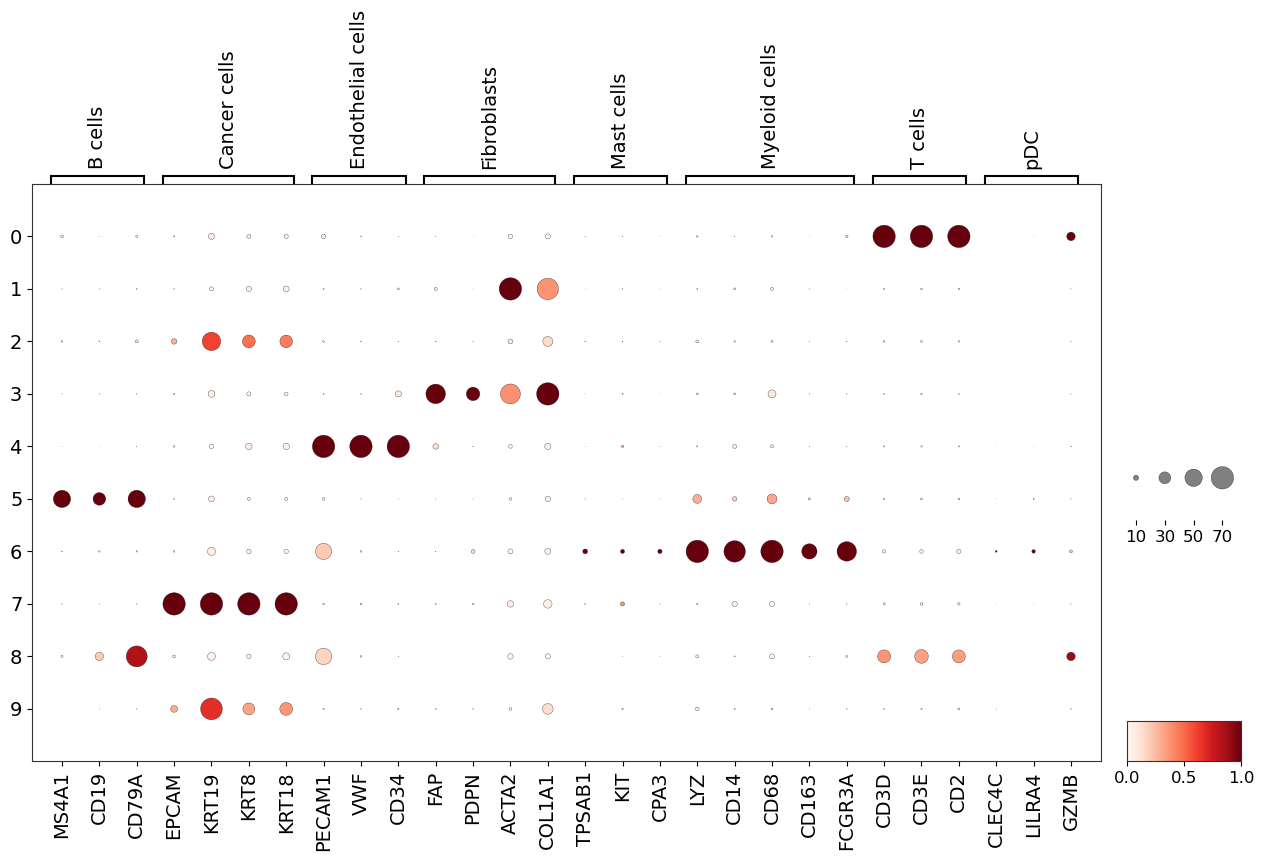

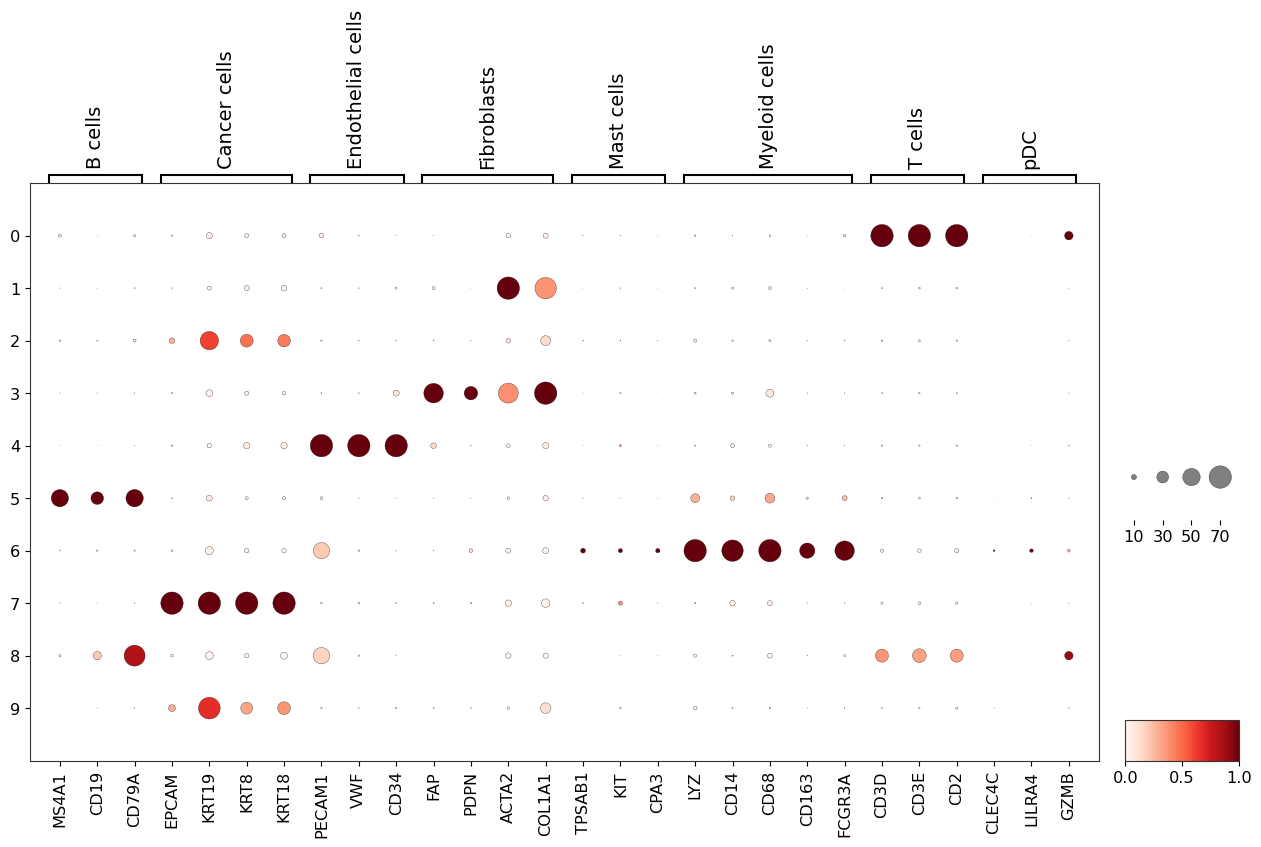

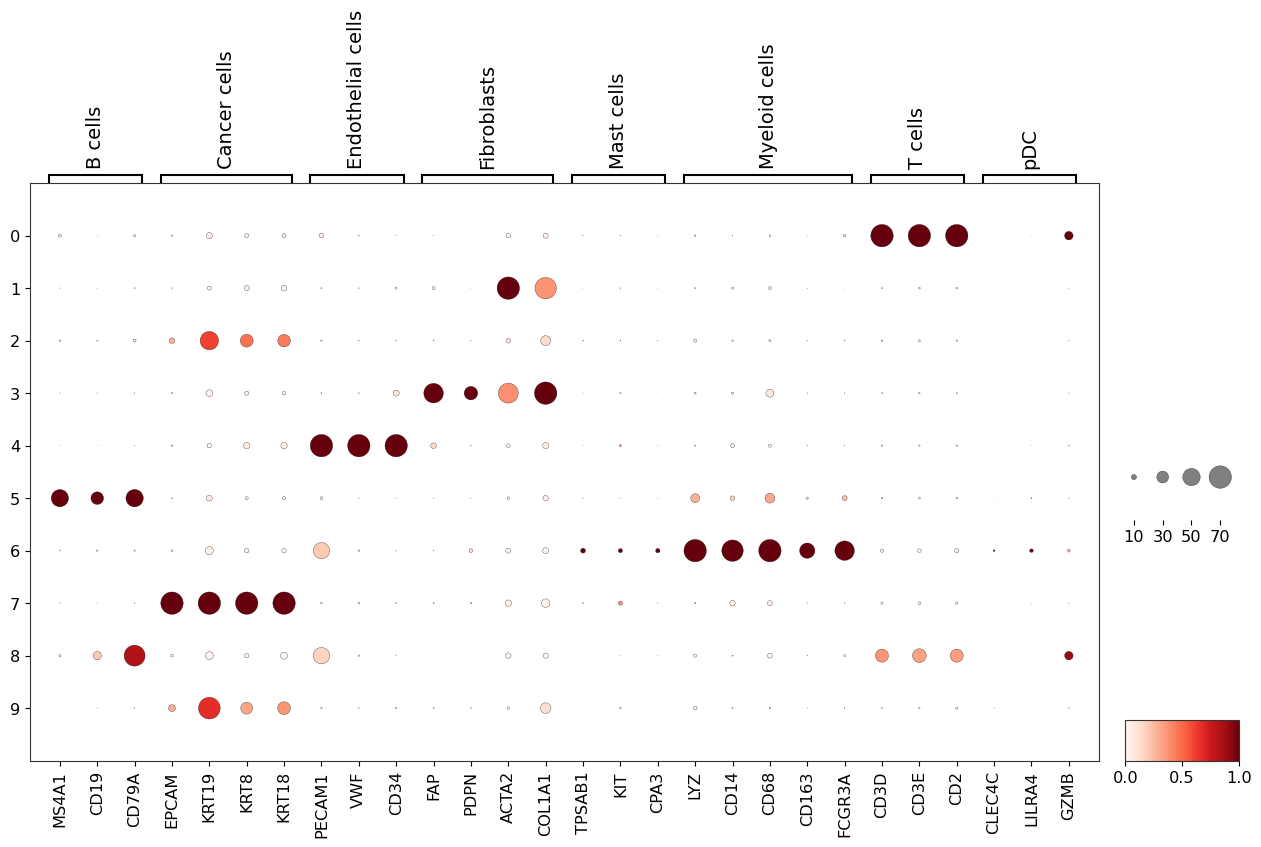

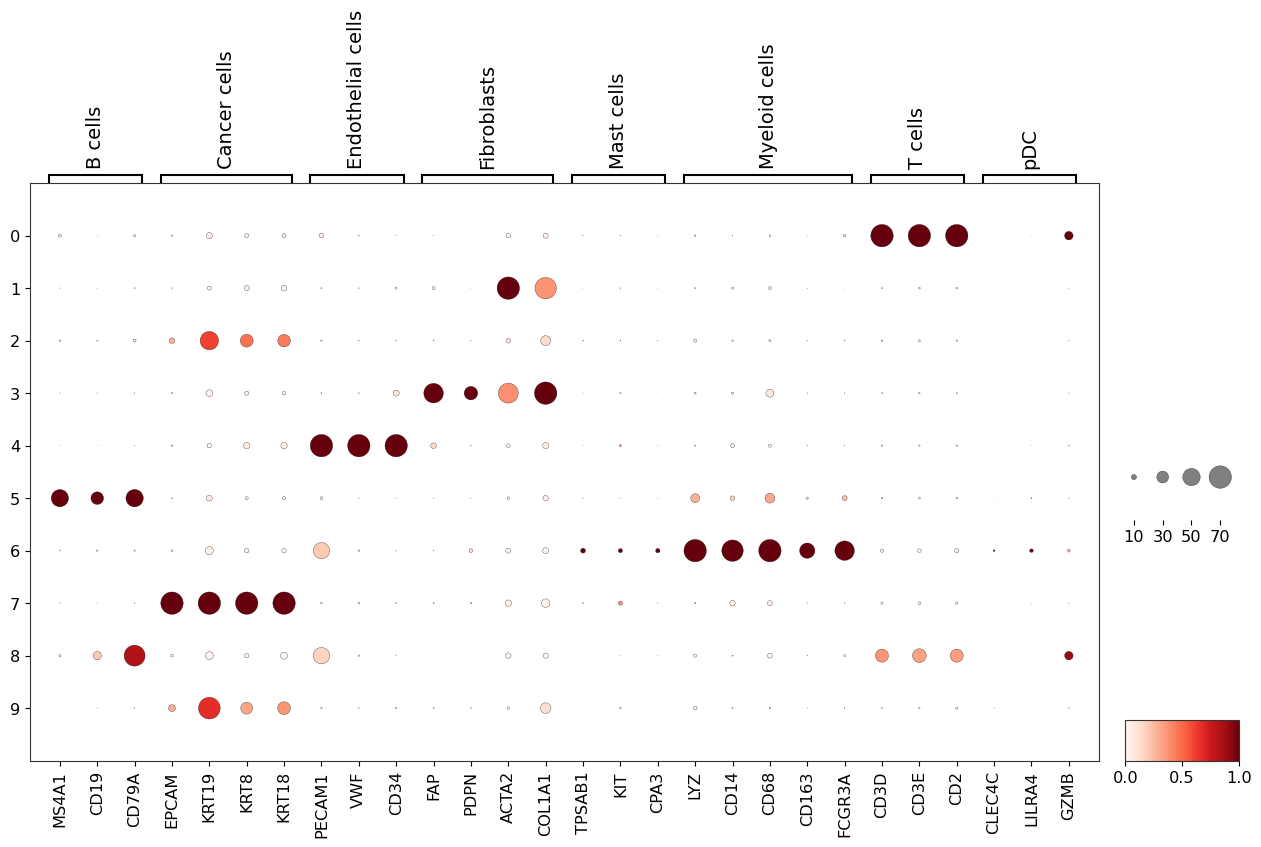

Saved figure PNG: plots/dotplot_geneformer_v1_continue.png
Saved figure PDF: plots/dotplot_geneformer_v1_continue.pdf
Saved figure SVG: plots/dotplot_geneformer_v1_continue.svg
Saved table values: fig3_metrics/dotplot_geneformer_v1_continue_values.csv
Saved table cluster_sizes: fig3_metrics/dotplot_geneformer_v1_continue_cluster_sizes.csv
Saved table enrichment: fig3_metrics/dotplot_geneformer_v1_continue_enrichment.csv
Saved table cell_type_best_clusters: fig3_metrics/dotplot_geneformer_v1_continue_cell_type_best_clusters.csv
Saved caption: fig3_metrics/dotplot_geneformer_v1_continue_caption.txt

Caption draft:
Dot plot of canonical tumor microenvironment (TME) marker genes across Leiden clusters (resolution 0.3) derived from Geneformer V1 continue embeddings in pre-treatment BRCA tumor cells (n=26,697 cells, 10 clusters). Dot size indicates the fraction of cells with detectable expression; color indicates mean log-normalized expression (scaled per gene). Embedding-derived clusters re

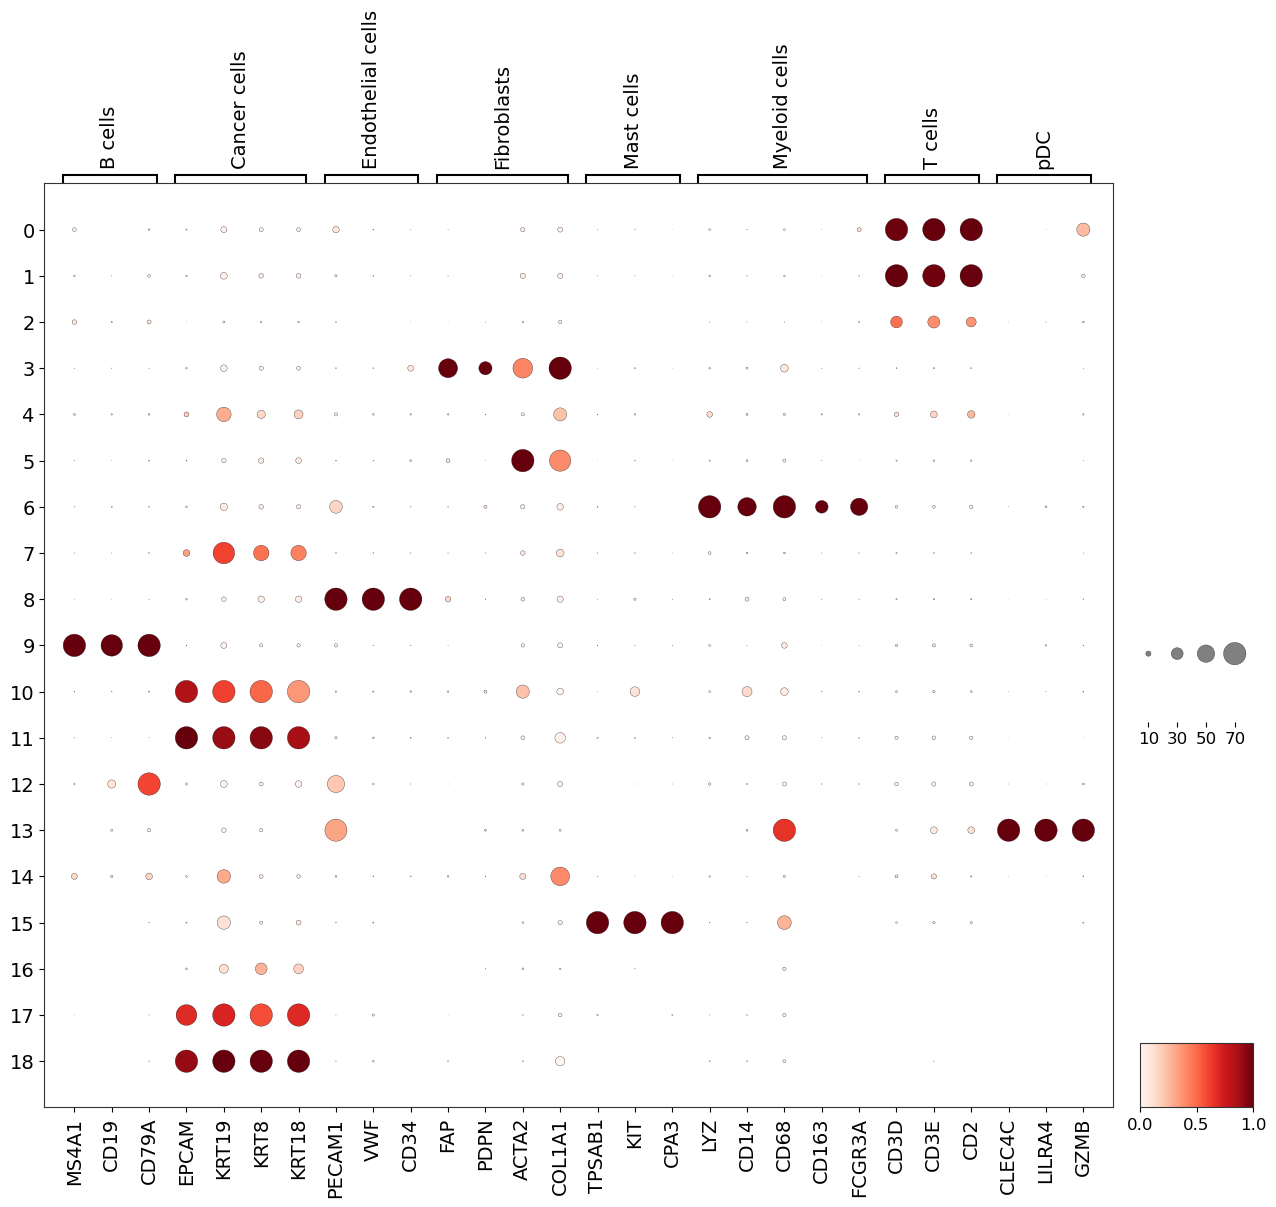

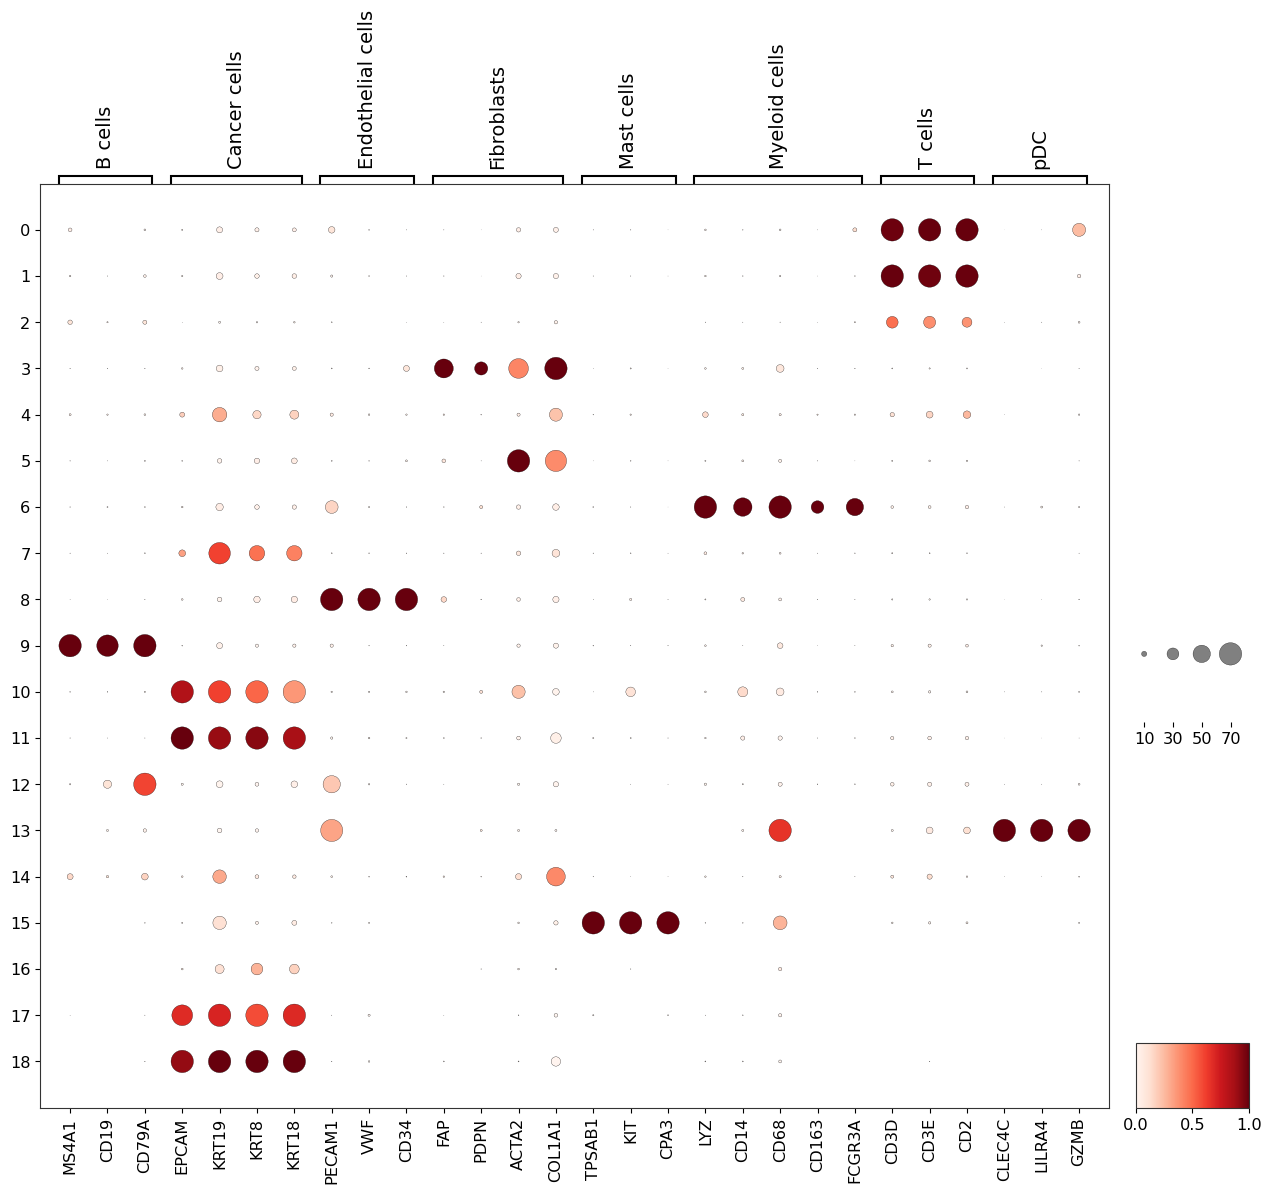

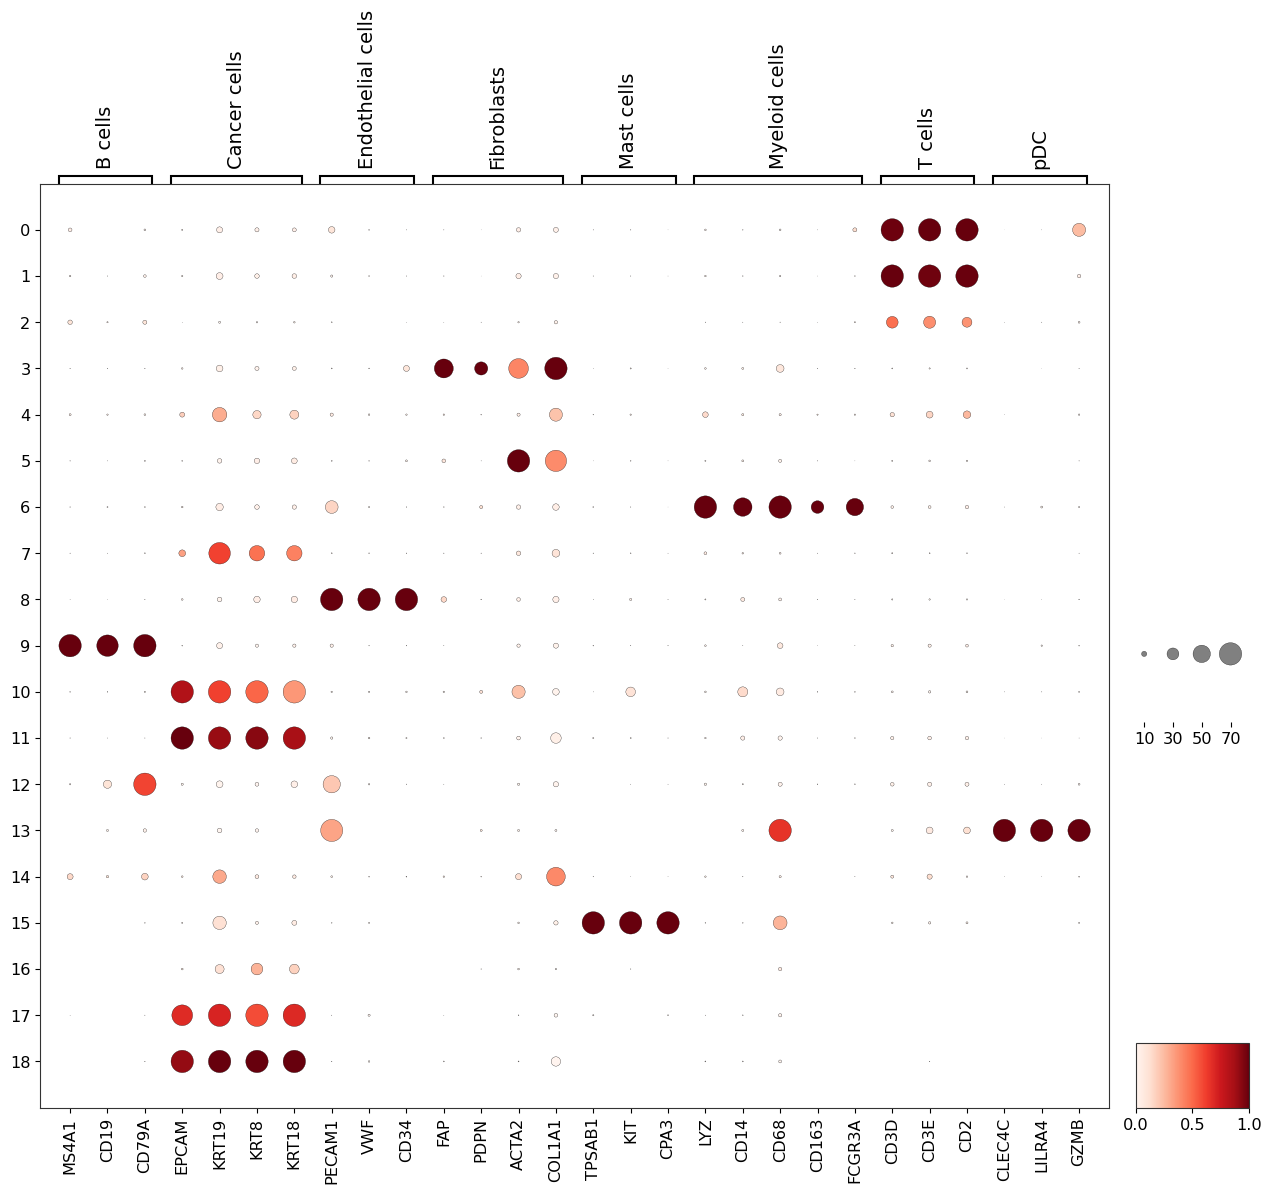

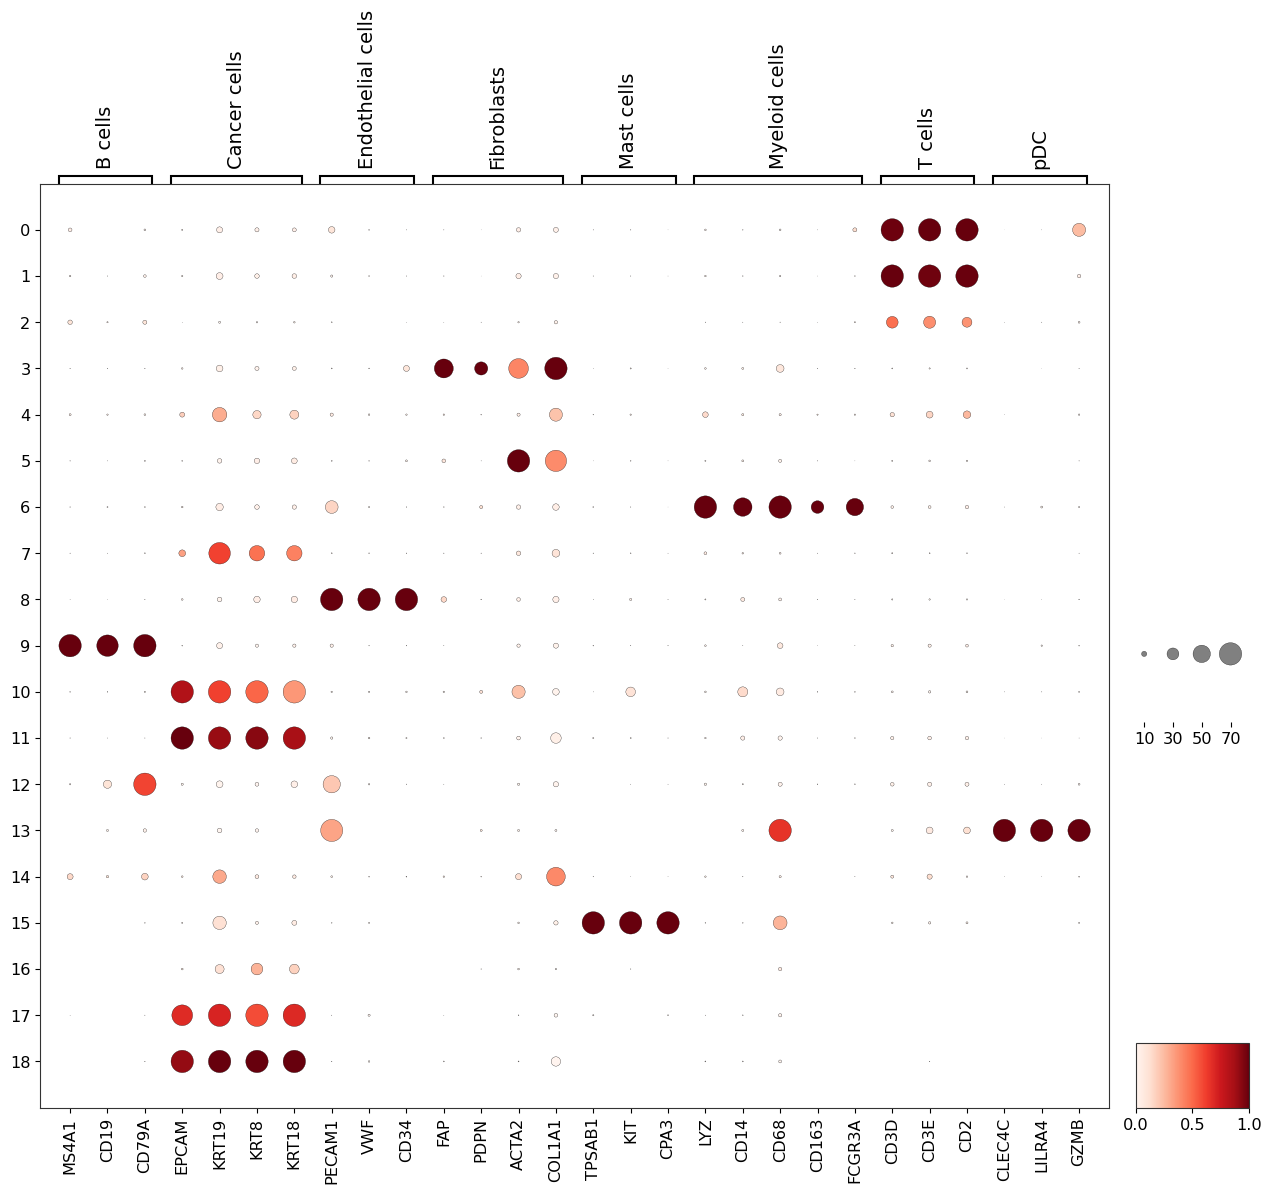

Saved figure PNG: plots/dotplot_gf2_continue.png
Saved figure PDF: plots/dotplot_gf2_continue.pdf
Saved figure SVG: plots/dotplot_gf2_continue.svg
Saved table values: fig3_metrics/dotplot_gf2_continue_values.csv
Saved table cluster_sizes: fig3_metrics/dotplot_gf2_continue_cluster_sizes.csv
Saved table enrichment: fig3_metrics/dotplot_gf2_continue_enrichment.csv
Saved table cell_type_best_clusters: fig3_metrics/dotplot_gf2_continue_cell_type_best_clusters.csv
Saved caption: fig3_metrics/dotplot_gf2_continue_caption.txt

Caption draft:
Dot plot of canonical tumor microenvironment (TME) marker genes across Leiden clusters (resolution 0.3) derived from Geneformer V2 continue embeddings in pre-treatment BRCA tumor cells (n=26,697 cells, 19 clusters). Dot size indicates the fraction of cells with detectable expression; color indicates mean log-normalized expression (scaled per gene). Embedding-derived clusters recovered expected marker structure, with the strongest enrichments including Mast

{'Geneformer V1 continue': {'figures': {'png': PosixPath('plots/dotplot_geneformer_v1_continue.png'),
   'pdf': PosixPath('plots/dotplot_geneformer_v1_continue.pdf'),
   'svg': PosixPath('plots/dotplot_geneformer_v1_continue.svg')},
  'tables': {'values':     cluster    gene  mean_expression  fraction_expressing  \
   0         0    CD19         0.004039             0.002157   
   1         0   CD79A         0.047023             0.030085   
   2         0   MS4A1         0.075238             0.044948   
   3         0   EPCAM         0.023682             0.015342   
   4         0   KRT18         0.120247             0.072756   
   ..      ...     ...              ...                  ...   
   275       9    CD3D         0.020165             0.011142   
   276       9    CD3E         0.039329             0.016713   
   277       9  CLEC4C         0.007051             0.002786   
   278       9    GZMB         0.015900             0.008357   
   279       9  LILRA4         0.000000    

In [3]:
def run_dotplot_for_model(reference_adata: ad.AnnData, model_cfg: dict) -> dict:
    """Cluster cells from embeddings and save figures, tables, and a caption."""
    embedded = ad.read_h5ad(model_cfg["embedding_path"])
    print(f"\n=== {model_cfg['label']} ===")
    print(f"Embedded cells: {embedded.n_obs:,}")

    cluster_from_embedding(
        embedded,
        EMBEDDING_KEY,
        cluster_key=CLUSTER_KEY,
        resolution=LEIDEN_RESOLUTION,
    )
    print(f"Leiden clusters: {embedded.obs[CLUSTER_KEY].nunique()}")

    adata = reference_adata.copy()
    transfer_clusters(embedded, adata, cluster_key=CLUSTER_KEY)

    result = make_publication_dotplot(
        adata,
        model_cfg["output_stem"],
        marker_dict=TME_MARKER_DICT,
        groupby=CLUSTER_KEY,
        model_label=model_cfg["label"],
        metrics_dir=METRICS_DIR,
        leiden_resolution=LEIDEN_RESOLUTION,
        show=True,
    )

    for fmt, path in result["figures"].items():
        print(f"Saved figure {fmt.upper()}: {path}")
    for name, path in result["table_paths"].items():
        print(f"Saved table {name}: {path}")
    print(f"Saved caption: {result['caption_path']}")
    print(f"\nCaption draft:\n{result['caption']}\n")
    return result


results = {cfg["label"]: run_dotplot_for_model(reference, cfg) for cfg in MODELS}
results


In [4]:
caption_lines = []
for label, result in results.items():
    caption_lines.append(f"## {label}\n")
    caption_lines.append(result["caption"])
    caption_lines.append("")

combined_captions = "\n".join(caption_lines)
combined_caption_path = METRICS_DIR / "figure_captions.md"
combined_caption_path.write_text(combined_captions + "\n")

print(combined_captions)
print(f"\nSaved combined captions: {combined_caption_path}")

## Geneformer V1 continue

Dot plot of canonical tumor microenvironment (TME) marker genes across Leiden clusters (resolution 0.3) derived from Geneformer V1 continue embeddings in pre-treatment BRCA tumor cells (n=26,697 cells, 10 clusters). Dot size indicates the fraction of cells with detectable expression; color indicates mean log-normalized expression (scaled per gene). Embedding-derived clusters recovered expected marker structure, with the strongest enrichments including Cancer cells markers in cluster 7 (91% expressing cells), Endothelial cells markers in cluster 4 (79% expressing cells), T cells markers in cluster 0 (79% expressing cells). Per-cluster marker statistics are provided in the accompanying tables.

## Geneformer V2 continue

Dot plot of canonical tumor microenvironment (TME) marker genes across Leiden clusters (resolution 0.3) derived from Geneformer V2 continue embeddings in pre-treatment BRCA tumor cells (n=26,697 cells, 19 clusters). Dot size indicates the fract